In [1]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

In [2]:
%%duckdb -o df_trips



CREATE OR REPLACE TABLE trips AS

SELECT
*, 
sqrt(
    power("end station latitude" - "start station latitude",2 ) + power("end station longitude"- "start station longitude",2) 
) AS distance_between_stations,

hour(start_at) as day_of_time,
CASE 
    WHEN hour(start_at) between 6 and 11 THEN 'morning'
    WHEN hour(start_at) between 12 and 17 THEN 'afternoon'
    WHEN hour(start_at) between 18 and 21 THEN 'evening'
    else 'night'
END AS time_of_day,

CASE 
WHEN dayofweek(start_at) IN (0,6) THEN 1 ELSE 0  
END AS is_weekends_indicator,

1 AS bias,
date_diff('minute', start_at, stop_at) AS duration_min

FROM (
    SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'    
    
)
WHERE duration_min between 1 and 180



,Count
0,23721615


In [3]:
%%duckdb

SELECT * 
FROM trips 
Limit 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,distance_between_stations,day_of_time,time_of_day,is_weekends_indicator,bias,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,0.035658,0,night,0,1,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,0.005786,0,night,0,1,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,0.008417,0,night,0,1,6


In [4]:
%%duckdb -o df_trips
SELECT * 
FROM trips USING SAMPLE 300000;

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,distance_between_stations,day_of_time,time_of_day,is_weekends_indicator,bias,duration_min
0,325,E 19 St & 3 Ave,40.736245,-73.984738,393,E 5 St & Avenue C,40.722992,-73.979955,19595,Subscriber,1969.0,2,2016-06-24 20:03:01,2016-06-24 20:29:22,0.014090,20,evening,0,1,26
1,386,Centre St & Worth St,40.714948,-74.002345,319,Fulton St & Broadway,40.711066,-74.009447,15801,Subscriber,1979.0,1,2016-06-17 15:10:27,2016-06-17 15:14:13,0.008094,15,afternoon,0,1,4
2,3233,E 48 St & 5 Ave,40.757246,-73.978059,3153,E 71 St & 2 Ave,40.768175,-73.959103,22510,Subscriber,1976.0,2,2016-10-15 17:46:20,2016-10-15 17:58:04,0.021882,17,afternoon,1,1,12
3,503,E 20 St & Park Ave,40.738274,-73.987520,263,Elizabeth St & Hester St,40.717290,-73.996375,17411,Subscriber,1990.0,1,2015-08-31 17:23:38,2015-08-31 17:41:13,0.022776,17,afternoon,0,1,18
4,476,E 31 St & 3 Ave,40.743943,-73.979661,379,W 31 St & 7 Ave,40.749156,-73.991600,17630,Subscriber,1983.0,1,2016-10-17 23:00:54,2016-10-17 23:06:26,0.013028,23,night,0,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,382,University Pl & E 14 St,40.734927,-73.992005,257,Lispenard St & Broadway,40.719392,-74.002472,16776,Subscriber,1979.0,2,2015-09-23 17:20:27,2015-09-23 17:35:28,0.018732,17,afternoon,0,1,15
299996,426,West St & Chambers St,40.717548,-74.013221,345,W 13 St & 6 Ave,40.736494,-73.997044,14624,Subscriber,1976.0,1,2015-05-01 16:56:02,2015-05-01 17:12:39,0.024913,16,afternoon,0,1,16
299997,281,Grand Army Plaza & Central Park S,40.764397,-73.973715,3168,Central Park West & W 85 St,40.784727,-73.969617,23834,Customer,NaN,0,2015-11-21 13:48:29,2015-11-21 14:35:04,0.020738,13,afternoon,1,1,47
299998,446,W 24 St & 7 Ave,40.744876,-73.995299,461,E 20 St & 2 Ave,40.735877,-73.982050,25683,Subscriber,1962.0,1,2016-09-20 17:47:25,2016-09-20 17:56:17,0.016016,17,afternoon,0,1,9


In [5]:
import pandas as pd 
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

x = df_trips[["distance_between_stations","time_of_day","is_weekends_indicator","bias"]]
x_new = pd.get_dummies(x, columns =["time_of_day"], drop_first =True)

y =df_trips["duration_min"]

x_train,x_val, y_train, y_val = train_test_split(x_new,y, test_size =0.2, random_state =42)

model =LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_val)
print(f"RMSE: {np.sqrt(mean_squared_error(y_val,y_pred))}\n")
print(f"R2 Score: {r2_score(y_val,y_pred):.4f}")


RMSE: 12.43016275592948

R2 Score: 0.0110


r2 score neden bu kadar düsük cikti bilmiyorum?

### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speek_{bike} = x | gender = a)
$$

- Note that $P(speek_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speek_{bike} = x | gender = a)$ modeled

In [6]:
%%duckdb -o df_gender


SELECT gender, distance_between_stations / duration_min as biker_speed
FROM trips
WHERE gender IN (1,2) 
and duration_min > 0 
and distance_between_stations > 0
ORDER BY biker_speed desc


,gender,biker_speed
0,1,84.477081
1,1,42.238541
2,1,42.238541
3,2,28.159842
4,1,28.157978
...,...,...
20516481,1,0.000004
20516482,1,0.000004
20516483,1,0.000003
20516484,1,0.000003


In [7]:
import numpy as np
from scipy import stats


male_spd = df_gender[df_gender["gender"] ==1]["biker_speed"]
female_spd =df_gender[df_gender["gender"] == 2]["biker_speed"]

#prior calc.
male = len(male_spd)/ len(df_gender)
female = len(female_spd)/len(df_gender)


mean_m = np.mean(male_spd)
std_m = np.std(male_spd)
mean_f = np.mean(female_spd)
std_f =np.std(female_spd)


In [8]:
def predict_gender(speed):
    likelihood_m = (1 / (std_m * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((speed - mean_m)/ std_m) **2)
    posterior_m = likelihood_m * male
    likelihood_f = (1 / (std_f * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((speed - mean_f)/ std_f) **2)
    posterior_f = likelihood_f * female

    if posterior_m > posterior_f:
        return 1 
    else:
        return 2



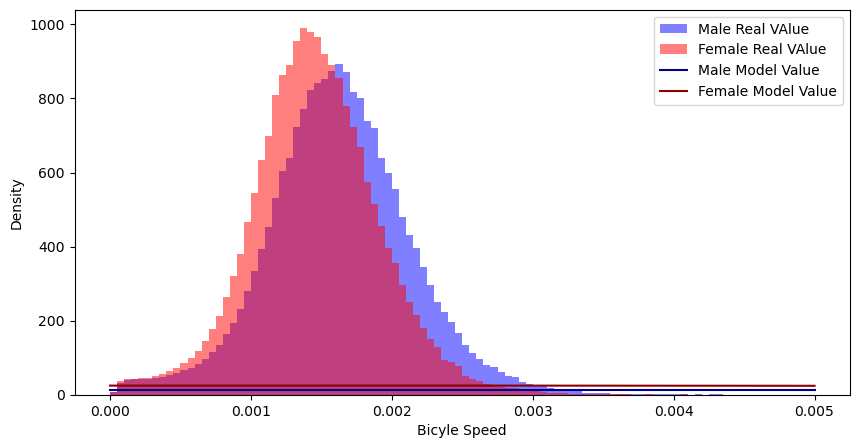

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(male_spd, bins=100, range=(0, 0.005),density =True, color= "blue",alpha=0.5, label = "Male Real VAlue")
plt.hist(female_spd, bins=100, range=(0, 0.005),density =True, color= "red",alpha=0.5, label = "Female Real VAlue")

x = np.linspace(0, 0.005 , 1000)
y_male =(1 / (std_m * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_m)/ std_m) **2)
y_female = (1 / (std_f * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_f)/ std_f) **2)
plt.plot(x,y_male, color="darkblue", label="Male Model Value")
plt.plot(x,y_female, color="darkred", label="Female Model Value")


plt.xlabel("Bicyle Speed")
plt.ylabel("Density")
plt.legend()
plt.show()